# Laboratorio de regresión - 2

## Significancia de factores

|                |   |
:----------------|---|
| **Nombre**     |  Claudio Alejo Encarnación Martínez |
| **Fecha**      |  31 agosto 2026 |
| **Expediente** | 750597  |

Descarga el archivo de publicidad y carga los datos (Advertising.csv).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/Advertising.csv')

In [2]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


**¿Hay alguna relación entre el presupuesto para publicidad y las ventas?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- ¿Por qué? ¿Qué resultaría si nos diéramos cuenta de la falta de relación entre el presupuesto de publicidad y las ventas?

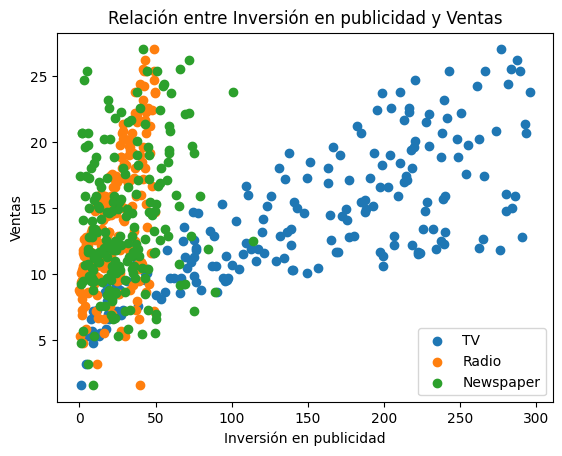

In [4]:
plt.scatter(df['TV'], df['sales'])
plt.scatter(df['radio'], df['sales'])
plt.scatter(df['newspaper'], df['sales'])
plt.title('Relación entre Inversión en publicidad y Ventas')
plt.xlabel('Inversión en publicidad')
plt.ylabel('Ventas')
plt.legend(['TV', 'Radio', 'Newspaper'])
plt.show()

Viendo la gráfica se puede intuir que sí existe una relación entre las varibales, de forma más notoria con los datos de Tv, y no tna clara con Radio y Newspaper. 

**¿Qué tan fuerte es esta relación?**
Asumiendo que existe esta relación, ¿nos sirve conocer el impacto que tiene invertir en publicidad en las ventas?

Claro que nos sirve, siguiendo la misma intuición anterior podríamos deducir por ejemplo, que alguno de los tres medios genera muchas más ventas con menor inversión, con lo que se podría optimizar este gasto. 

**¿Cuáles medios están asociados con las ventas? ¿Qué tan grande es la asociación entre un medio específico y las ventas?**

Hay 3 medios distintos en los datos. ¿Sirve invertir en los 3? ¿Conviene más invertir sólo en uno?

**¿Qué tan seguros estamos de que podríamos predecir ventas futuras?**

**¿La relación es lineal?**

**¿Hay sinergia entre estos medios?**

Puede ser que gastar \\$50,000 en publicidad y otros \\$50,000 en radio es mejor opción que gastar \\$100,000 en televisión. A esto le llamamos efecto de interacción.

Podemos usar regresión lineal para responder todas estas preguntas.

Realiza una regresión lineal:

$$ \text{ventas} \approx \beta_0 + (\beta_1)(\text{TV})$$

In [5]:
Xv_TV = np.reshape(df['TV'].values, [-1, 1])
X_TV = Xv_TV
X_TV

Xv_Radio = np.reshape(df['radio'].values, [-1, 1])
X_Radio = Xv_Radio

Xv_Newspaper = np.reshape(df['newspaper'].values, [-1, 1])
X_Newspaper = Xv_Newspaper


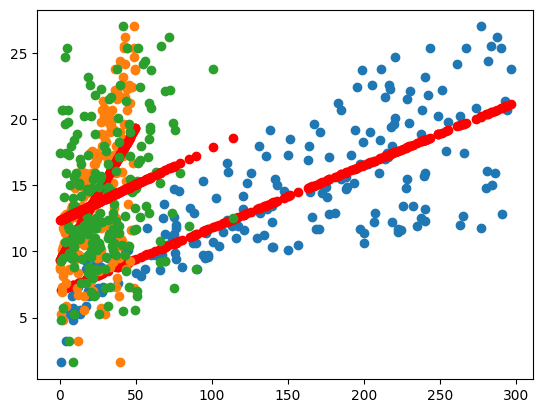

In [6]:
lr_TV = LinearRegression()
lr_TV.fit(X_TV, df['sales'])

lr_Radio = LinearRegression()
lr_Radio.fit(X_Radio, df['sales'])

lr_Newspaper = LinearRegression()
lr_Newspaper.fit(X_Newspaper, df['sales'])

plt.scatter(df['TV'], df['sales'])
plt.scatter(df['TV'], lr_TV.predict(X_TV), color='red')

plt.scatter(df['radio'], df['sales'])
plt.scatter(df['radio'], lr_Radio.predict(X_Radio), color='red')

plt.scatter(df['newspaper'], df['sales'])
plt.scatter(df['newspaper'], lr_Newspaper.predict(X_Newspaper), color='red')



In [7]:
b0_TV = lr_TV.intercept_
b1_TV = lr_TV.coef_[0]
b0_Radio = lr_Radio.intercept_
b1_Radio = lr_Radio.coef_[0]
b0_Newspaper = lr_Newspaper.intercept_
b1_Newspaper = lr_Newspaper.coef_[0]
print("Beta 0 para TV:", b0_TV, ", Beta 1 para TV:", b1_TV)
print("Beta 0 para Radio:", b0_Radio, ", Beta 1 para Radio:", b1_Radio)
print("Beta 0 para Newspaper:", b0_Newspaper, ", Beta 1 para Newspaper:", b1_Newspaper)

print("R^2 para TV:", lr_TV.score(X_TV, df['sales']))
print("R^2 para Radio:", lr_Radio.score(X_Radio, df['sales']))
print("R^2 para Newspaper:", lr_Newspaper.score(X_Newspaper, df['sales']))

Beta 0 para TV: 7.032593549127694 , Beta 1 para TV: 0.04753664043301976
Beta 0 para Radio: 9.311638095158283 , Beta 1 para Radio: 0.20249578339243965
Beta 0 para Newspaper: 12.351407069278162 , Beta 1 para Newspaper: 0.05469309847227335
R^2 para TV: 0.611875050850071
R^2 para Radio: 0.33203245544529525
R^2 para Newspaper: 0.05212044544430516


### Verificando la precisión de nuestros coeficientes estimados

Recuerda que en el mundo real hay ruidos y errores de medición. Siempre se asume que la verdadera relación entre $X$ y $Y$ es $$Y = \beta_0 + \beta_1 X + \epsilon$$

Se asume que el término de error es independiente de $X$ (el error siempre es el mismo sin importar el valor de $X$). Este modelo describe a la *línea de regresión de la población*, que es la mejor aproximación de la verdadera relación entre $X$ y $Y$. Cuando usamos mínimos cuadrados encontramos la *línea de mínimos cuadrados*.

¿Cuál es la diferencia entre población y muestra?

RESPUESTA:

La población se puede entender como el conjunto de todos los datos reales y completos de X situación que estemos analizando; obviamente en temas de estadística entendemos a la población como algo que jamás tendremos realmente, es imposible tener todos los datos reales de algo que conceptualmente es infinito.

¿Cuál crees que sea la diferencia entre hacer una regresión con todos los datos de la población y una muestra de ella?

RESPUESTA:

Pues que al momento de adaptar nuestra regresión sobre solo una muestra, sí podremos representar en cierta medida la realidad de la población pero con cierto margen de error, el cual se toma en cuenta con los diferentes niveles de confianza que utilizamos en los modelos estadísticos.

La línea de regresión de la población no se puede observar. El concepto de comparar estas líneas es una extensión natural del acercamiento estadístico estándar de usar información de una muestra para estimar características de una población grande.

Imagina que quieres encontrar la altura promedio de un mexicano $\mu$. Medir a todos y cada uno de los mexicanos en situaciones similares, con la misma regla, mismo operador, y otras incontables formas de minimizar la variación de la medida es una tarea imposible. Lo que podemos asumir es que $\hat{\mu} = \bar{y}$. La media poblacional y la media muestral son diferentes, pero la media muestral es usualmente un buen estimado.

De la misma manera, como no contamos con el 100% de la información para hacer una regresión, los coeficientes $\beta_0$ y $\beta_1$ son desconocidos. Podemos estimarlos usando mínimos cuadrados, encontrando $\hat{\beta_0}$ y $\hat{\beta_1}$. Puede que las muestras que tengamos en ese momento estén un poco por encima de la media, pero otras muestras en otro momento puede que estén debajo de la media. En general, esperamos que el promedio de las aproximaciones $\hat{\mu}$ aproxime a $\mu$.

Esto lleva a la pregunta: ¿qué tan cercanos son nuestros coeficientes estimados a los verdaderos coeficientes? Utilizamos el concepto de error estándar para evaluar esto.

$$ \text{Var}(\hat{\mu})=\text{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n} $$

Donde $\sigma$ es la desviación estándar de cada una de las observaciones $y_i$ de $Y$. El error estándar nos dice la cantidad promedio que el estimado difiere del valor verdadero. Podemos ver en la fórmula que entre más observaciones tengamos el error se hace más pequeño. Las fórmulas para errores estándar de $\hat{\beta_0}$ y $\hat{\beta_1}$ son:

$$ \text{SE}(\hat{\beta_0})^2 = \sigma^2 [\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}]$$

$$ \text{SE}(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$ \sigma^2 = \text{Var}(\epsilon) = \text{RSE}^2 = \frac{\text{RSS}}{n-p}$$

Para que estas fórmulas sean validas asumimos que los errores $\epsilon_i$ tienen varianza común $\sigma^2$ y que no están correlacionados.

Calcula los errores estándar de los coeficientes

In [8]:
#Error estandar de beta 0 de TV
X_barra_TV=np.mean(df['TV'])
Suma_diferencia_cuadrada_b0TV=df['TV'] - X_barra_TV
Suma_diferencia_cuadrada_b0TV = Suma_diferencia_cuadrada_b0TV**2
Suma_diferencia_cuadrada_b0TV =np.sum(Suma_diferencia_cuadrada_b0TV)

E_b0TV=df['sales'] - lr_TV.predict(X_TV)
E_b0TV=E_b0TV**2
RSS_b0TV=np.sum(E_b0TV)
sigma2_b0TV=RSS_b0TV/(200-2)
sigma2_b0TV

SE_b0TV=np.sqrt(sigma2_b0TV*((1/200) + (X_barra_TV**2)/Suma_diferencia_cuadrada_b0TV))
SE_b0TV


np.float64(0.45784294027347855)

In [9]:
#Error estandar de beta 1 de TV
SE_b1TV=np.sqrt(sigma2_b0TV/(Suma_diferencia_cuadrada_b0TV))
SE_b1TV

np.float64(0.0026906071877968707)

In [10]:
#Error estandar de beta 0 de Radio
X_barra_Radio=np.mean(df['radio'])
Suma_diferencia_cuadrada_b0Radio=df['radio'] - X_barra_Radio
Suma_diferencia_cuadrada_b0Radio = Suma_diferencia_cuadrada_b0Radio**2
Suma_diferencia_cuadrada_b0Radio =np.sum(Suma_diferencia_cuadrada_b0Radio)

E_b0Radio=df['sales'] - lr_Radio.predict(X_Radio)
E_b0Radio=E_b0Radio**2
RSS_b0Radio=np.sum(E_b0Radio)
sigma2_b0Radio=RSS_b0Radio/(200-2)
sigma2_b0Radio

SE_b0Radio=np.sqrt(sigma2_b0Radio*((1/200) + (X_barra_Radio**2)/Suma_diferencia_cuadrada_b0Radio))
SE_b0Radio


np.float64(0.5629004962718711)

In [11]:
#Error estandar de beta 1 de Radio
SE_b1Radio=np.sqrt(sigma2_b0Radio/(Suma_diferencia_cuadrada_b0Radio))
SE_b1Radio

np.float64(0.020411306360090635)

In [12]:
#Error estandar de beta 0 de Newspaper
X_barra_Newspaper=np.mean(df['newspaper'])
Suma_diferencia_cuadrada_b0Newspaper=df['newspaper'] - X_barra_Newspaper
Suma_diferencia_cuadrada_b0Newspaper = Suma_diferencia_cuadrada_b0Newspaper**2
Suma_diferencia_cuadrada_b0Newspaper =np.sum(Suma_diferencia_cuadrada_b0Newspaper)

E_b0Newspaper=df['sales'] - lr_Newspaper.predict(X_Newspaper)
E_b0Newspaper=E_b0Newspaper**2
RSS_b0Newspaper=np.sum(E_b0Newspaper)
sigma2_b0Newspaper=RSS_b0Newspaper/(200-2)
sigma2_b0Newspaper

SE_b0Newspaper=np.sqrt(sigma2_b0Newspaper*((1/200) + (X_barra_Newspaper**2)/Suma_diferencia_cuadrada_b0Newspaper))
SE_b0Newspaper

np.float64(0.6214201876094345)

In [13]:
#Error estandar de beta 0 de Newspaper
SE_b1Newspaper=np.sqrt(sigma2_b0Newspaper/(Suma_diferencia_cuadrada_b0Newspaper))
SE_b1Newspaper

np.float64(0.016575721876358165)

Estos errores se pueden usar para calcular intervalos de confianza. Un intervalo de confianza del $95\%$ se define como un rango de valores en el cuál se encuentra el desconocido valor verdadero con un $95\%$ de probabilidad.

Otra forma de verlo es que si tomamos muestras repetidas y construimos un intervalo de confianza para cada una, el $95\%$ de los intervalos creados van a contener el valor verdadero. Para la regresión el intervalo de confianza del $95\%$ toma la forma:

$$ \hat{\beta_j} \pm 2\text{SE}(\hat{\beta_j})$$

Calcula los intervalos de confianza para los coeficientes estimados:

In [14]:
#INTERVALOS DE CONFIANZA
print("Intervalo de confianza para beta cero TV: [", b0_TV - 2*SE_b0TV,",", b0_TV + 2*SE_b0TV, "]")
print("Intervalo de confianza para beta uno TV: [", b1_TV - 2*SE_b1TV,",", b1_TV + 2*SE_b1TV, "]")

print("Intervalo de confianza para beta cero Radio: [", b0_Radio - 2*SE_b0Radio,",", b0_Radio + 2*SE_b0Radio, "]")
print("Intervalo de confianza para beta uno Radio: [", b1_Radio - 2*SE_b1Radio,",", b1_Radio + 2*SE_b1Radio, "]")

print("Intervalo de confianza para beta cero Newspaper: [", b0_Newspaper - 2*SE_b0Newspaper,",", b0_Newspaper + 2*SE_b0Newspaper, "]")
print("Intervalo de confianza para beta uno Newspaper: [", b1_Newspaper - 2*SE_b1Newspaper,",", b1_Newspaper + 2*SE_b1Newspaper, "]")

Intervalo de confianza para beta cero TV: [ 6.116907668580737 , 7.948279429674651 ]
Intervalo de confianza para beta uno TV: [ 0.04215542605742602 , 0.052917854808613496 ]
Intervalo de confianza para beta cero Radio: [ 8.185837102614542 , 10.437439087702025 ]
Intervalo de confianza para beta uno Radio: [ 0.1616731706722584 , 0.2433183961126209 ]
Intervalo de confianza para beta cero Newspaper: [ 11.108566694059293 , 13.59424744449703 ]
Intervalo de confianza para beta uno Newspaper: [ 0.02154165471955702 , 0.08784454222498968 ]


Los errores estándar también se usan para realizar pruebas de hipótesis. La prueba de hipótesis más común es probar la hipótesis nula de:

$$ H_0: \text{No hay relación entre } X \text{ y } Y \ \ \ \ (\beta_1=0)$$

contra la hipótesis alternativa:
$$ H_0: \text{Hay alguna relación entre } X \text{ y } Y \ \ \ (\beta_1 \neq 0)$$

Explica con tus palabras el significado de la hipótesis nula y la hipótesis alternativa.

La hipótesis nula bajo el contexto en el que estamos ahorita, se podría entender como la confirmación (estadísticamente) de que no hay relación entre las variables, mientras que la hipótesis alternativa sugiere que sí existe relación (bajo ciertos límites e intervalos de confianza sobre los cuales diseñemos la prueba)

Para probal la hipótesis nula debemos determinar si nuestro estimado $\hat{\beta_1}$ de $\beta_1$ está lo suficientemente alejado de cero para que podamos decir con confianza que este valor no es cero. 

¿Qué tan lejos? Depende de qué tanta confianza tengamos en el estimado encontrado. Si nuestro error estándar es pequeño y nuestro estimado está alejado de cero podríamos decir que hay muy poca probabilidad de que el valor verdadero sea 0. En cambio, si nuestro error estándar es grande y nuestro estimado está muy cerca de cero, entonces podrías ser que el valor verdadero sea cero y que no haya relación entre las variables.

Se calcula un *estadístico t* dado por
$$ t = \frac{\hat{\beta_j} - \mu}{\text{SE}(\hat{\beta_j})} $$

donde $\mu$ es el valor contra el que queremos probar.

Calcula el estadístico t para tus coeficientes estimados, usando como referencia la prueba de hipótesis.

In [15]:
from scipy import stats

In [17]:


t_b1TV=b1_TV/SE_b1TV
t_b0TV=b0_TV/SE_b0TV

print("Estadístico t para beta 0 TV:", t_b0TV)
print("Estadístico t para beta 1 TV:", t_b1TV)

t_b1Radio=b1_Radio/SE_b1Radio
t_b0Radio=b0_Radio/SE_b0Radio

print("Estadístico t para beta 0 Radio:", t_b0Radio)
print("Estadístico t para beta 1 Radio:", t_b1Radio)

t_b1Newspaper=b1_Newspaper/SE_b1Newspaper
t_b0Newspaper=b0_Newspaper/SE_b0Newspaper

print("Estadístico t para beta 0 Newspaper:", t_b0Newspaper)
print("Estadístico t para beta 1 Newspaper:", t_b1Newspaper)


Estadístico t para beta 0 TV: 15.360275174117543
Estadístico t para beta 1 TV: 17.66762560087555
Estadístico t para beta 0 Radio: 16.542245311258217
Estadístico t para beta 1 Radio: 9.920765472824959
Estadístico t para beta 0 Newspaper: 19.87609562024895
Estadístico t para beta 1 Newspaper: 3.2995907436334178


La distribución t tiene forma de campana y se parece bastante a la distribución normal cuando $n > 30$. Ya sólo es cuestión de calcular la probabilidad de observar cualquier número tal que su valor absoluto sea igual o mayor que el valor absoluto del estadístico t calculado. En otras palabras:
$$ P(|x| \geq |t|) $$

A esta probabilidad la llamamos *p-value*. Un *p-value* pequeño indica que es poco probable que exista por puro azar una relación significativa entre predictor y respuesta, en caso de que no haya una asociación real entre predictor y respuesta. En otras palabras, el *p-value* te dice la probabilidad de que parezca que hay relación cuando no la hay.

Si el *p-value* es pequeño, inferimos que sí hay una asociación entre el predictor y la respuesta, y **rechazamos la hipótesis nula**.
  

¿Qué tan pequeño? Depende de la aplicación. Un valor muy común es del $5\%$.

Utiliza el siguiente código para calcular el *p-value* para tus coeficientes

`from scipy import stats`

`p_bj = 2*(1 - stats.t.cdf(np.abs(t_bj), n-p))`

In [18]:

p_b1TV=2*(1-stats.t.cdf(np.abs(t_b1TV), 198))
p_b0TV=2*(1-stats.t.cdf(np.abs(t_b0TV), 198))

print("P value para beta 0 TV:", p_b0TV)
print("P value para beta 1 TV:", p_b1TV)

p_b1Radio=2*(1-stats.t.cdf(np.abs(t_b1Radio), 198))
p_b0Radio=2*(1-stats.t.cdf(np.abs(t_b0Radio), 198))

print("P value para beta 0 Radio:", p_b0Radio)
print("P value para beta 1 Radio:", p_b1Radio)

p_b1Newspaper=2*(1-stats.t.cdf(np.abs(t_b1Newspaper), 198))
p_b0Newspaper=2*(1-stats.t.cdf(np.abs(t_b0Newspaper), 198))

print("P value para beta 0 Newspaper:", p_b0Newspaper)
print("P value para beta 1 Newspaper:", p_b1Newspaper)

P value para beta 0 TV: 0.0
P value para beta 1 TV: 0.0
P value para beta 0 Radio: 0.0
P value para beta 1 Radio: 0.0
P value para beta 0 Newspaper: 0.0
P value para beta 1 Newspaper: 0.0011481958688881466


¿Se rechaza la hipótesis nula? ¿Qué significa?

RESPUESTA:
Como el p-value es menor a 0.05 (por nivel de significancia escogido) para todos los valores de beta de las 3 variables (tv, radio, newspaper), podemos concluir con un 95% de confianza que NOOO es coincidencia que los datos se comporten de esa manera, sí existe una relación lo suficientemente significativa (no sabemos que tan fuerte es solo con esta prueba) entre cada variable y ventas (de forma separada)

Realiza otras dos regresiones. Ya tienes hecha la regresión de ventas dado el gasto en publicidad de TV. Realiza la regresión para gastos en radio y gastos en periódico. Organiza las respuestas para que debajo de esta celda se tenga:
- Título de regresión
- Coeficientes estimados
- Errores estándar de los coeficientes
- Intervalos de confianza
- Estadísticos t
- p-values
- Observaciones

RESPUESTA:
**Ya resuelto a lo largo de la tarea**

## Regresión lineal múltiple

En lugar de hacer una regresión para cada factor independiente, quizás se puede extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

Para nuestro ejemplo de publicidad:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

Utiliza la librería `statsmodels` para realizar la regresión. Por defecto la librería statsmodels no toma en cuenta el intercepto ($\beta_0$), por lo que se tendrá que agregar una columna de unos de tamaño *n* a la matriz X.

`import statsmodels.api as sm`

`ols = sm.OLS(Y, X)`

`results = ols.fit()`

`results.summary()`

In [23]:
import statsmodels.api as sm

In [25]:

ones = np.ones((len(df), 1))

ols = sm.OLS(df['sales'], np.hstack((ones, X_TV, X_Radio, X_Newspaper)))

results = ols.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        14:29:56   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [27]:
#Correlación entre variables
df[['TV', 'radio', 'newspaper', 'sales']].corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


¿Qué diferencias puedes observar entre los *p-values* de una regresión múltiple y los encontrados en las regresiones simples? ¿Por qué crees que existen estas diferencias?

Los de TV y Radio se mantienen muy buenos, mientras que el p-value de Newspaper cambia mucho (se pasó al lado de la hipótesis nula) y nos indica que a pesar de que en la regresión lineal simple pareciera que Newspaper sí está fuertemente relacionado con las ventas, en realidad esto se debe a una correlación Radio-Newspaper y no Newspaper-Ventas. Esto se concluye con ayuda de la tabla de correlaciones. Esta regresión múltiple es mucho más fiable en este caso porque toma en cuenta pesos matemáticos de las variables que la regresión simple no toma en cuenta.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3

## Addendum

Para calcular los *p-values* de los parámetros sin `statsmodels`:
1. Calcular RSS
2. Calcular RSE
3. `var_beta = np.linalg.inv(X.T @ X) * rse**2` (X con columna de intercepto)
4. `std_beta = np.sqrt(var_beta.diagonal())` El orden de los valores corresponde al orden de los factores en las columnas de la matriz $X$.
5. Calcular *estadístico t*
6. Calcular *p-value*